# Part c


For this part of exercise 2 we run a GPT-4o-mini in a zero-shot setting, meaning the model only receives a natural language task description via a prompt and no labeled examples from the dataset are given. One design choice we made is set the tempreature to 0 for deterministic, reproducible predictions.

Since zero-shot uses no training data, there is no train/test split to worry about, none of the labeled data were ever seen by the model so evaluation on tehm involves no leaakage or "double dipping".

We do two evaluations:

- We first evaluate on the same approx. 7 example validation set used in the other parts of exercise 2
- The second evaluation is done on the 32 labeled examples

The second evaluation is valid precisely because zero-shot does no training, every labeled example is genuinely unseen, so we can use all 32 labeled examples for a more stable estimate without contaminating the results.



## Setup

In [ ]:
from datasets import load_dataset, DatasetDict
import pandas as pd
from utils import preprocess_for_bert
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from openai import OpenAI
import time
from tqdm import tqdm
from sklearn.metrics import classification_report
import numpy as np

# ── Seed ──────────────────────────────────────────────────────────────────────
seed = 123
def set_seed(seed=123):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(seed)


from dotenv import load_dotenv
import os

load_dotenv() 


### Load and process data

In [4]:
# ── Load & preprocess data ────────────────────────────────────────────────────
df = pd.read_csv("../data/filtered_reviews.csv")
df['review'] = df['review'].apply(preprocess_for_bert)

print(f"Full dataset: {df.shape}")
print(df['stars'].value_counts(dropna=False))

# Only keep rows that have a label
labeled_df = df.dropna(subset=['stars', 'review'])
texts  = labeled_df['review'].tolist()
labels = (labeled_df['stars'].astype(int) - 1).tolist()  # 0-indexed

# ── 32-label constraint: sample 32 labeled rows, rest treated as unlabeled ────
rng = np.random.default_rng(seed)
labeled_idx = rng.choice(len(texts), size=32, replace=False)

texts_32  = [texts[i]  for i in labeled_idx]
labels_32 = [labels[i] for i in labeled_idx]

# ── Train/valid split on the 32 labeled examples (~25 train / 7 valid) ────────
train_texts, valid_texts, train_labels, valid_labels = train_test_split(
    texts_32, labels_32, test_size=0.2, stratify=labels_32, random_state=seed
)

# Lowercase (consistent with other parts)
train_texts = [t.lower() for t in train_texts]
valid_texts = [t.lower() for t in valid_texts]

print(f"\n32-label split → train: {len(train_texts)}, valid: {len(valid_texts)}")


Full dataset: (10776, 6)
stars
NaN    10744
1.0        9
5.0        7
3.0        6
2.0        5
4.0        5
Name: count, dtype: int64

32-label split → train: 25, valid: 7


#### Set up the API

In [5]:
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

### Call model via API and run on 7 labeled examples

In [ ]:
# ── Zero-shot prediction function ─────────────────────────────────────────────
def predict_star_rating(review_text: str) -> int | None:
    """
    Zero-shot: the model sees NO labeled examples from the dataset.
    It classifies purely from the task description in the system prompt.
    """
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        max_tokens=5,
        temperature=0,          # deterministic / reproducible
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a Trustpilot review classifier. "
                    "Given a customer review, predict the star rating. "
                    "Respond with ONLY a single digit: 1, 2, 3, 4, or 5. "
                    "No explanation, no punctuation — just the digit."
                )
            },
            {
                "role": "user",
                "content": f'Review: """{review_text}"""\n\nStar rating:'
            }
        ]
    )
    raw = response.choices[0].message.content.strip()
    try:
        rating = int(raw[0])
        if rating in range(1, 6):
            return rating - 1   # convert to 0-indexed
    except (ValueError, IndexError):
        pass
    return None

# ── Run on validation set (same ~7 rows used in all other parts) ──────────────
llm_preds = []
failed = 0

for text in tqdm(valid_texts, desc="GPT-4o-mini zero-shot"):
    pred = predict_star_rating(text)
    if pred is None:
        pred = 2        # fallback: middle class
        failed += 1
    llm_preds.append(pred)
    time.sleep(0.1)

print(f"Parse failures: {failed}/{len(valid_texts)}")

# ── Evaluate ──────────────────────────────────────────────────────────────────
unique_labels = sorted(set(valid_labels))
label_names   = [f"{l + 1} star" for l in unique_labels]

print(classification_report(
    valid_labels, llm_preds,
    labels=unique_labels,
    target_names=label_names,
    zero_division=0
))

GPT-4o-mini zero-shot: 100%|██████████| 7/7 [00:05<00:00,  1.29it/s]

Parse failures: 0/7
              precision    recall  f1-score   support

      1 star       0.50      1.00      0.67         2
      2 star       0.00      0.00      0.00         1
      3 star       0.00      0.00      0.00         1
      4 star       1.00      1.00      1.00         1
      5 star       1.00      1.00      1.00         2

    accuracy                           0.71         7
   macro avg       0.50      0.60      0.53         7
weighted avg       0.57      0.71      0.62         7



### Results: first evaluation on aprox. 7 labeled examples

/Users/isa.adls/Documents/BSE_coursework/Advanced_NLP/advanced_nlp_final/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


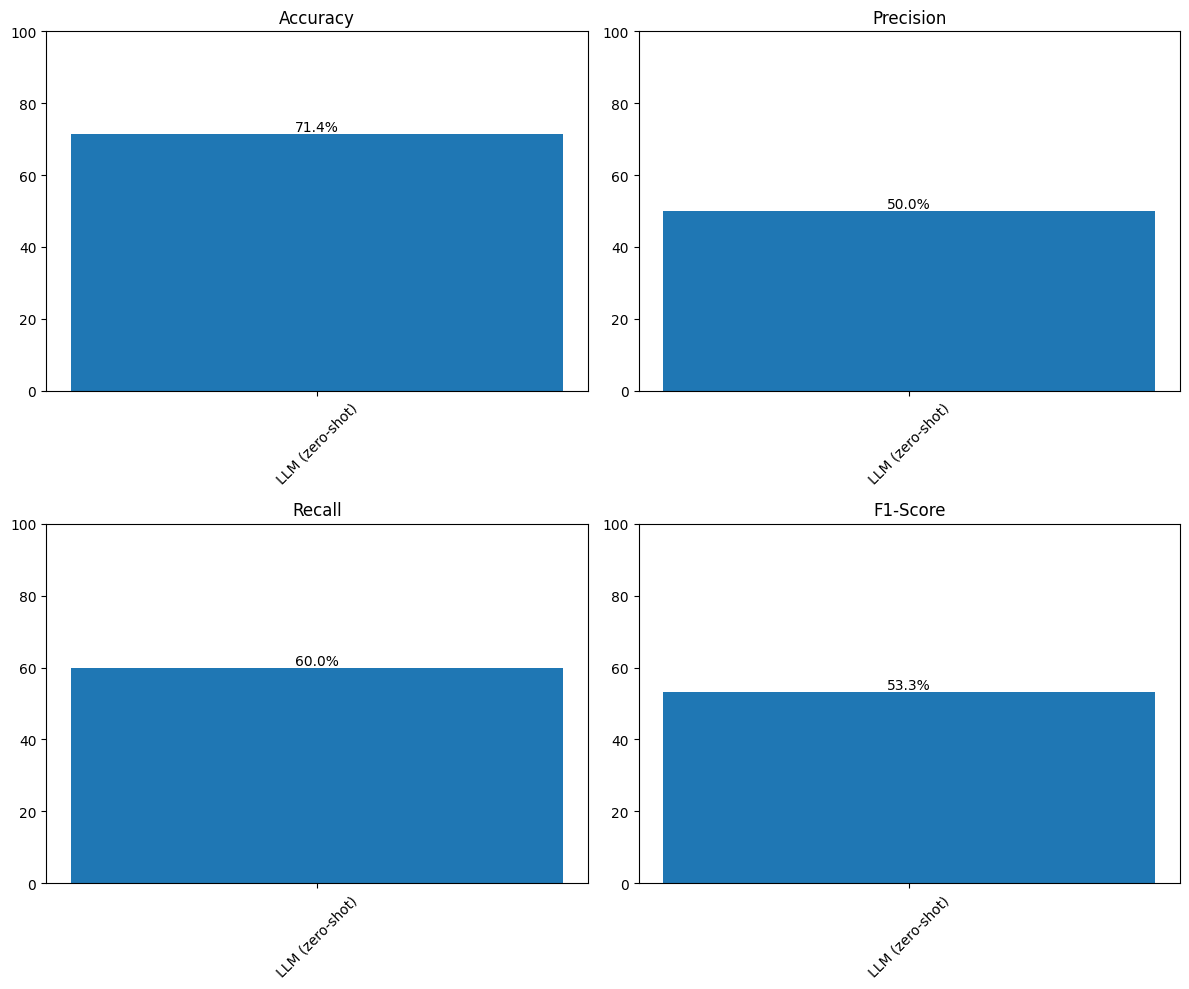

In [ ]:
from utils import Metrics

metrics_val = Metrics()

metrics_val.run(valid_labels, llm_preds, 'LLM (zero-shot)')
metrics_val.plot()

The lower F1-score motivated me to validate on the full 32 labeled examples because one error in the 7 really skews the results. none of the 32 were used for training so no double dipping happening.

### Call model via API and run on 32 labeled examples + results 

GPT-4o-mini zero-shot (all 32): 100%|██████████| 32/32 [00:22<00:00,  1.40it/s]

Parse failures: 0/32
              precision    recall  f1-score   support

      1 star       0.67      0.89      0.76         9
      2 star       0.40      0.40      0.40         5
      3 star       0.40      0.33      0.36         6
      4 star       1.00      0.60      0.75         5
      5 star       1.00      1.00      1.00         7

    accuracy                           0.69        32
   macro avg       0.69      0.64      0.66        32
weighted avg       0.70      0.69      0.68        32



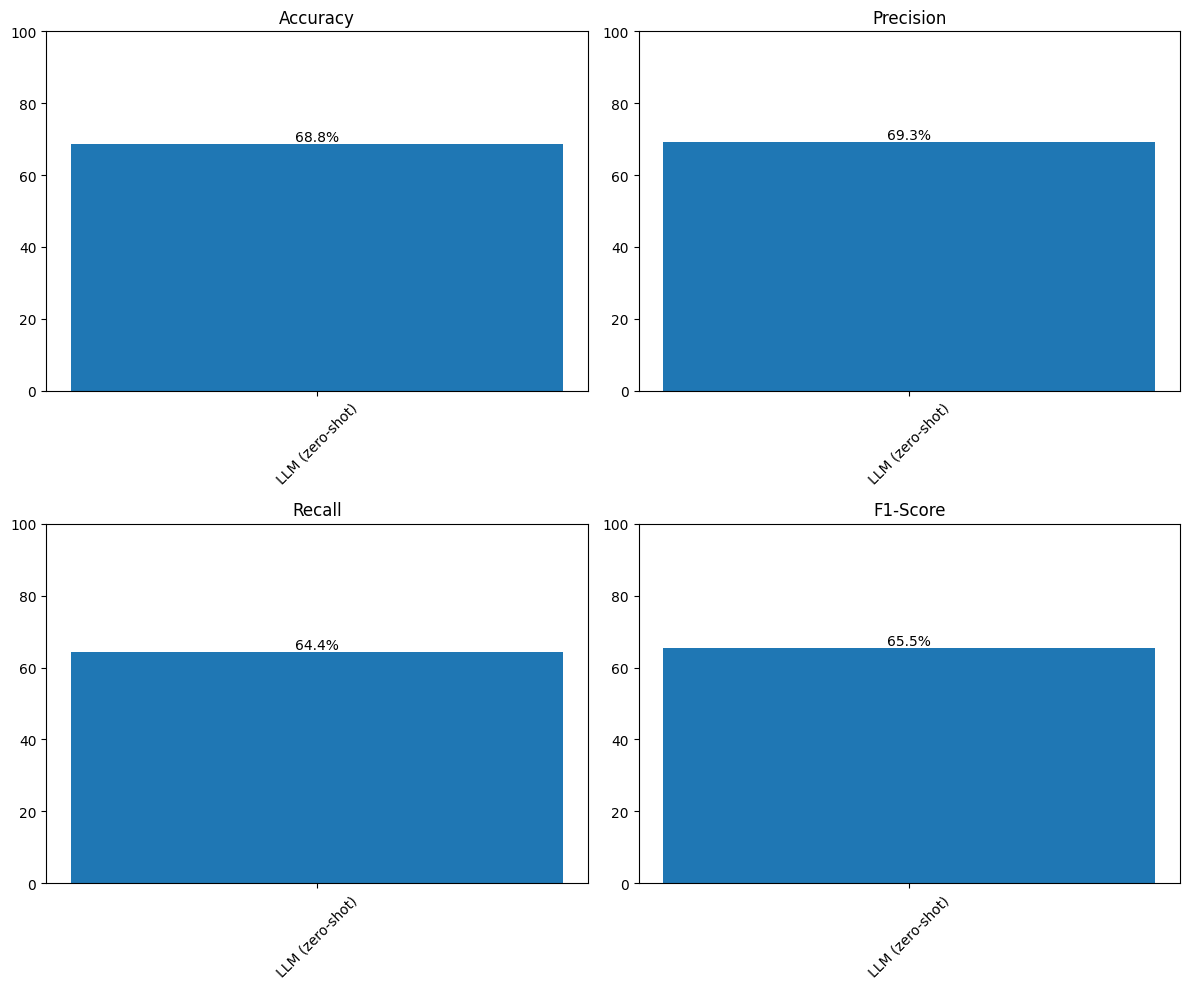

In [ ]:
# ── Evaluate zero-shot on all 32 labeled examples ─────────────────────────────
# Zero-shot uses no training data, so we can use all 32 for evaluation

all32_texts  = [t.lower() for t in texts_32]
all32_labels = labels_32

llm_preds_32 = []
failed_32 = 0

for text in tqdm(all32_texts, desc="GPT-4o-mini zero-shot (all 32)"):
    pred = predict_star_rating(text)
    if pred is None:
        pred = 2
        failed_32 += 1
    llm_preds_32.append(pred)
    time.sleep(0.1)

print(f"Parse failures: {failed_32}/{len(all32_texts)}")

unique_labels_32 = sorted(set(all32_labels))
label_names_32   = [f"{l + 1} star" for l in unique_labels_32]

print(classification_report(
    all32_labels, llm_preds_32,
    labels=unique_labels_32,
    target_names=label_names_32,
    zero_division=0
))

##### Results
metrics_val.run(all32_labels, llm_preds_32, 'LLM (zero-shot)')
metrics_val.plot()

Zero-Shot LLM (GPT-4o-mini). We applied GPT-4o-mini in a zero-shot setting, providing only a natural language task description in the system prompt, no labeled examples from the Trustpilot dataset were shown to the model. On the 7-example validation set, the model achieved 71.4% accuracy and a macro F1 of 0.53. Performance was strong on extreme ratings (1-star and 5-star: F1 = 0.67 and 1.00 respectively) and collapsed on mid-range ratings (2-star and 3-star: F1 = 0.00), which is consistent with the known difficulty of ordinal sentiment classification, the semantic distance between adjacent middle classes is small and reviewer-idiosyncratic. Notably, this result was achieved with zero labeled examples, making it a strong baseline for the low-data regime.


On the 32-example validation set, the model achieved 68.8% accuracy and a macro F1 of 0.655. Performance once again struggled on the 2 and 3-star but with more support per class with 32 samples the picture is less extreme. Instead of 0% each we saw 40% and 36% F1-scores respectively. This suggests the 7-example results were partly an artifact of the tiny validation size rather than a complete failure on those classes. 